In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader
from torchvision import transforms
from torchvision import models
import torch.nn as nn
from torchinfo import summary



# Data Exploration

In [3]:
dataset_path= Path("/Users/jocelynsickler/Documents/Master's Degree/MSc IT+ Summer Project/plant-a-patch/plant-disease-identifier/PlantVillage-Dataset")

# Get the classes in the dataset
classes = sorted([folder.name for folder in dataset_path.iterdir() if folder.is_dir()])
print(f"Classes in dataset: {classes}")
print(f"Number of classes: {len(classes)} \n")

# Get the number of images in each class and total number of images in the dataset
total_images = 0
for class_name in classes:
    class_path = dataset_path / class_name

    num_images = len([file.name for file in class_path.iterdir() if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png']])

    print(f"Number of images in class '{class_name}' : {num_images}")

    # Add the number of images in this class to the total number of images
    total_images += num_images

print(f"\nTotal number of images in dataset: {total_images}")




Classes in dataset: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

Text(0.5, 1.0, 'Class Distribution in PlantVillage Dataset')

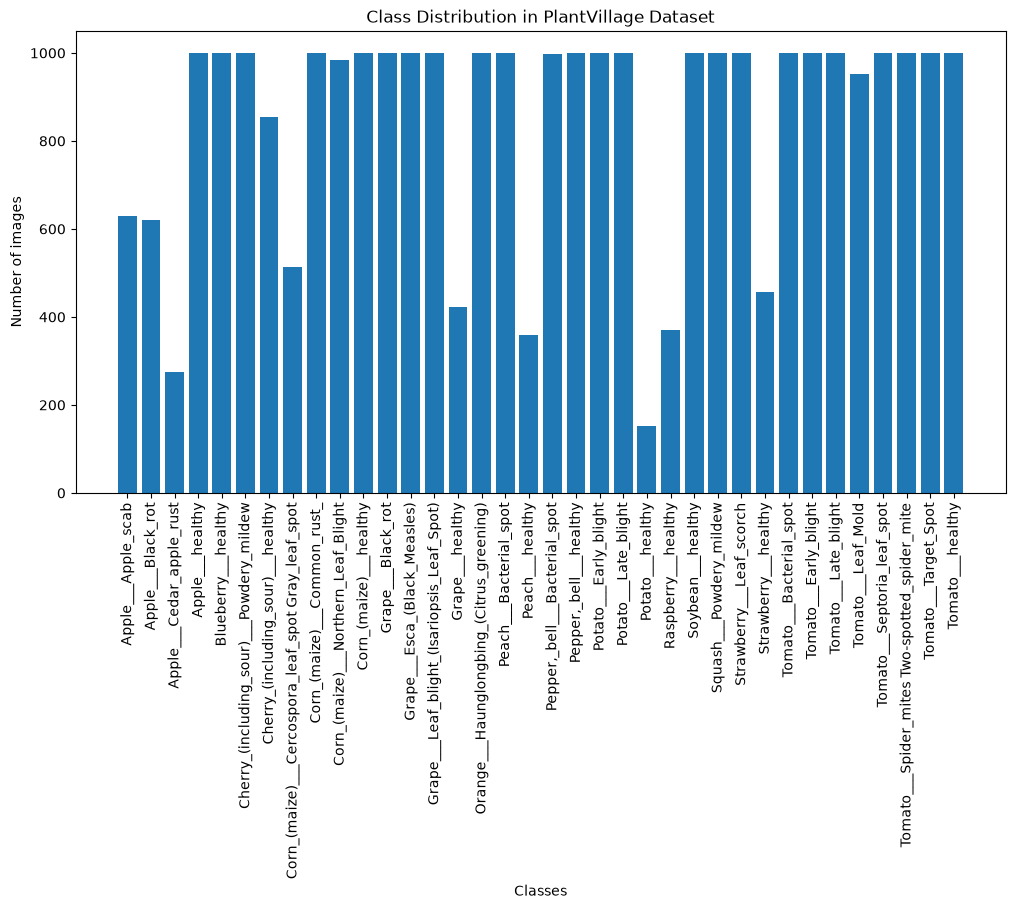

In [4]:
# Visualise the number of images in each class using a bar chart
num_images_per_class = []

for class_name in classes:
    class_path = dataset_path / class_name

    num_images = len([file.name for file in class_path.iterdir() if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png']])

    num_images_per_class.append(num_images)

plt.figure(figsize=(12, 6))
plt.bar(classes, num_images_per_class)
plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Class Distribution in PlantVillage Dataset")

# Create Dataset

In [5]:
dataset = ImageFolder(root=dataset_path)
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Class names and labels: {dataset.class_to_idx}")

Number of samples: 30589
Number of classes: 36
Class names and labels: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot

# Data Transformations

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5707283].


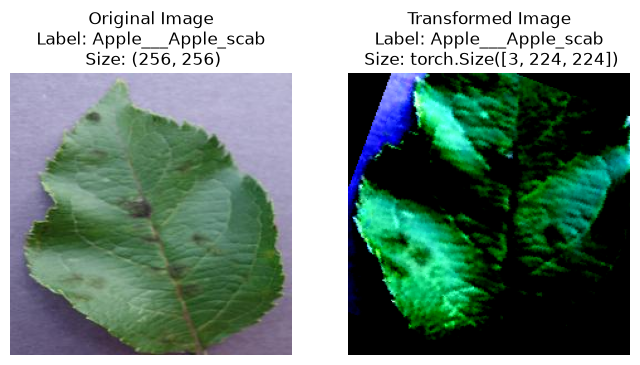

In [32]:
# Data transformations
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop images to 224x224 pixels
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip images horizontally 50% of the time
    transforms.RandomRotation(degrees=30), # Randomly rotate images by up to 30 degrees
    transforms.ToTensor(), # Convert images to Pytorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalise images using the mean and standard deviation of the ImageNet dataset
])

# Don't flip or rotate validation and test images

val_transform = transforms.Compose([
    transforms.Resize(256), # Resize images to 256x256 pixels
    transforms.CenterCrop(224), # Crop the centre to 224x224 pixels
    transforms.ToTensor(), # Convert images to Pytorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalise images using the mean and standard deviation of the ImageNet dataset
])

test_transform = transforms.Compose([
    transforms.Resize(256), # Resize images to 256x256 pixels
    transforms.CenterCrop(224), # Crop the centre to 224x224 pixels
    transforms.ToTensor(), # Convert images to Pytorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalise images using the mean and standard deviation of the ImageNet dataset
])



image, label = dataset[0]
tensor_image = train_transform(image)

# Visualise the original and transformed images
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original Image\nLabel: {dataset.classes[label]}\n Size: {image.size}")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(tensor_image.permute(1, 2, 0))
plt.title(f"Transformed Image\nLabel: {dataset.classes[label]}\n Size: {tensor_image.size()}")
plt.axis('off')

# Apply the transformations to the dataset
train_dataset_full = ImageFolder(root=dataset_path, transform=train_transform)
val_dataset_full = ImageFolder(root=dataset_path, transform=val_transform)
test_dataset_full = ImageFolder(root=dataset_path, transform=test_transform)


# Split Data into Training, Validation, and Testing Sets

In [7]:
# Code block generated by ChatGPT, comments added by me to aid in understanding

# Get the label for each sample in the dataset
labels = [label for _, label in dataset.samples]

# Assign an index to each sample in the dataset
indices = list(range(len(dataset)))

# Split once to get the training set (70% of dataset) and a temporary set (30% of dataset)
# stratify ensures that the class distribution is preserved in the splits
train_indices, temp_indices = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)

# Get the label for each sample in the temporary set
temp_labels = [labels[i] for i in temp_indices]

# Split the temporary set into validation (15% of dataset) and test (15% of dataset) sets
val_indices, test_indices = train_test_split(temp_indices, test_size=0.50, stratify=temp_labels, random_state=42)

# Break the datset into training, validation, and test sets using the indices obained above
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)
test_dataset = Subset(test_dataset_full, test_indices)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")



Number of training samples: 21412
Number of validation samples: 4588
Number of test samples: 4589


# Create DataLoaders

In [8]:
# Turn datasets into dataloaders so we can iterate through them in batches
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # Use all available CPU cores for data loading

# Set seed for reproducibility
torch.manual_seed(42)

# Create dataloaders training, validation, and test datasets
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

images, labels = next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Model 1 (ResNet)

In [9]:
# Load pretrained ResNet-18 model from torchision
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [10]:
# Change the final layer of the model to match the number of classes in our dataset
in_features = model.fc.in_features
num_classes = len(dataset.classes)

model.fc = nn.Linear(in_features=in_features, out_features=num_classes)

# Print new final layer
print(model.fc)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

Linear(in_features=512, out_features=36, bias=True)


In [11]:
summary(model,
         input_size=(32, 3, 224, 224),
         verbose=0,
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 36]             --                   Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (36,864)             False
│    │    

In [12]:
# Loss function for muli-class classification
loss_fn = nn.CrossEntropyLoss()

# Optimiser for training the model
optimizer = torch.optim.SGD(model.fc.parameters(), lr=0.01) # lr = learning rate

In [13]:
def train_for_epoch(model, dataloader, loss_fn, optimizer, device):
    train_loss = 0

    correct_predictions = 0
    total_predictions = 0

    # Set the model to training mode
    model.train()

    # Loop through all batches in the dataloader
    for images, labels in dataloader:
        # Move images and labels to the device (GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        logits = model(images)
        predicted_labels = torch.argmax(logits, dim=1) # Get the class with the highest logit for each image in the batch

        # Calculate the loss
        loss = loss_fn(logits, labels)
        train_loss += loss.item() # Add loss for this batch to total loss

        # Zero gradients
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # Calulcate the accuracy
        correct_predictions += torch.eq(predicted_labels, labels).sum().item()
        total_predictions += len(labels)

    epoch_loss = train_loss / len(dataloader)
    epoch_accuracy = (correct_predictions / total_predictions) * 100
    return (epoch_loss, epoch_accuracy)

In [14]:
def validate_for_epoch(model, dataloader, loss_fn, device):
    val_loss = 0

    correct_predictions = 0
    total_predictions = 0

    # Set the model to evaluation mode
    model.eval()

    with torch.inference_mode():
        # Loop through all batches in the dataloader
        for images, labels in dataloader:
            # Move images and labels to the device (GPU or CPU)
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            logits = model(images)
            predicted_labels = torch.argmax(logits, dim=1) # Get the class with the highest logit for each image in the batch

            # Calculate the loss
            loss = loss_fn(logits, labels)
            val_loss += loss.item() # Add loss for this batch to total loss

            # Calculate the accuracy
            correct_predictions += torch.eq(predicted_labels, labels).sum().item()
            total_predictions += len(labels)

    epoch_loss = val_loss / len(dataloader)
    epoch_accuracy = (correct_predictions / total_predictions) * 100
    return (epoch_loss, epoch_accuracy)

In [306]:
torch.manual_seed(42)

NUM_EPOCHS = 10

# Set device to GPU to speed up training if available
if torch.cuda.is_available():
    device = torch.device("cuda") # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Apple Silicon GPU
else:
    device = torch.device("cpu")

model = model.to(device)

best_val_accuracy = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_for_epoch(model, train_dataloader, loss_fn, optimizer, device)
    val_loss, val_accuracy = validate_for_epoch(model, val_dataloader, loss_fn, device)

    # Save the model with the best validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_resnet_model.pth")

    print(f"** Epoch #{epoch + 1} out of {NUM_EPOCHS} **")
    print(f"Training Loss: {train_loss:.5f} | Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.2f}%\n")

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}% at Epoch #{best_epoch}")
print(f"Model with best validation accuracy saved as 'best_resnet_model.pth'")
    

** Epoch #1 out of 10 **
Training Loss: 0.49072 | Training Accuracy: 85.20%
Validation Loss: 0.26472 | Validation Accuracy: 91.52%

** Epoch #2 out of 10 **
Training Loss: 0.48733 | Training Accuracy: 84.89%
Validation Loss: 0.30201 | Validation Accuracy: 90.06%

** Epoch #3 out of 10 **
Training Loss: 0.47952 | Training Accuracy: 85.36%
Validation Loss: 0.26361 | Validation Accuracy: 91.43%

** Epoch #4 out of 10 **
Training Loss: 0.48091 | Training Accuracy: 85.22%
Validation Loss: 0.26587 | Validation Accuracy: 91.52%

** Epoch #5 out of 10 **
Training Loss: 0.47069 | Training Accuracy: 85.43%
Validation Loss: 0.25049 | Validation Accuracy: 92.00%

** Epoch #6 out of 10 **
Training Loss: 0.47893 | Training Accuracy: 85.37%
Validation Loss: 0.25821 | Validation Accuracy: 91.80%

** Epoch #7 out of 10 **
Training Loss: 0.46887 | Training Accuracy: 85.52%
Validation Loss: 0.26557 | Validation Accuracy: 91.35%

** Epoch #8 out of 10 **
Training Loss: 0.46938 | Training Accuracy: 85.58%


In [308]:
# Reload saved model with best validation accuracy for testing
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
num_classes = len(dataset.classes)

model.fc = nn.Linear(in_features=in_features, out_features=num_classes)

model.load_state_dict(torch.load("best_resnet_model.pth"))
model = model.to(device)




In [27]:
def test_model(model, dataloader, loss_fn, device):
    test_loss = 0

    correct_predictions = 0
    total_predictions = 0

    all_labels = []
    all_predicted_labels = []

    # Set the model to evaluation mode
    model.eval()

    with torch.inference_mode():
        # Loop through all batches in the dataloader
        for images, labels in dataloader:
            # Move images and labels to the device (GPU or CPU)
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            logits = model(images)
            predicted_labels = torch.argmax(logits, dim=1) # Get the class with the highest logit for each image in the batch

            # Add the true and predicted labels for this batch to the lists for later analysis
            all_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(predicted_labels.cpu().numpy())

            # Calculate the loss
            loss = loss_fn(logits, labels)
            test_loss += loss.item() # Add loss for this batch to total loss

            # Calculate the accuracy
            correct_predictions += torch.eq(predicted_labels, labels).sum().item()
            total_predictions += len(labels)
    
    epoch_loss = test_loss / len(dataloader)
    epoch_accuracy = (correct_predictions / total_predictions) * 100
    return (epoch_loss, epoch_accuracy, all_labels, all_predicted_labels)

In [311]:
# Test the model on the test dataset
test_loss, test_accuracy, all_labels, all_predicted_labels = test_model(model, test_dataloader, loss_fn, device)

print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.23315 | Test Accuracy: 92.46%


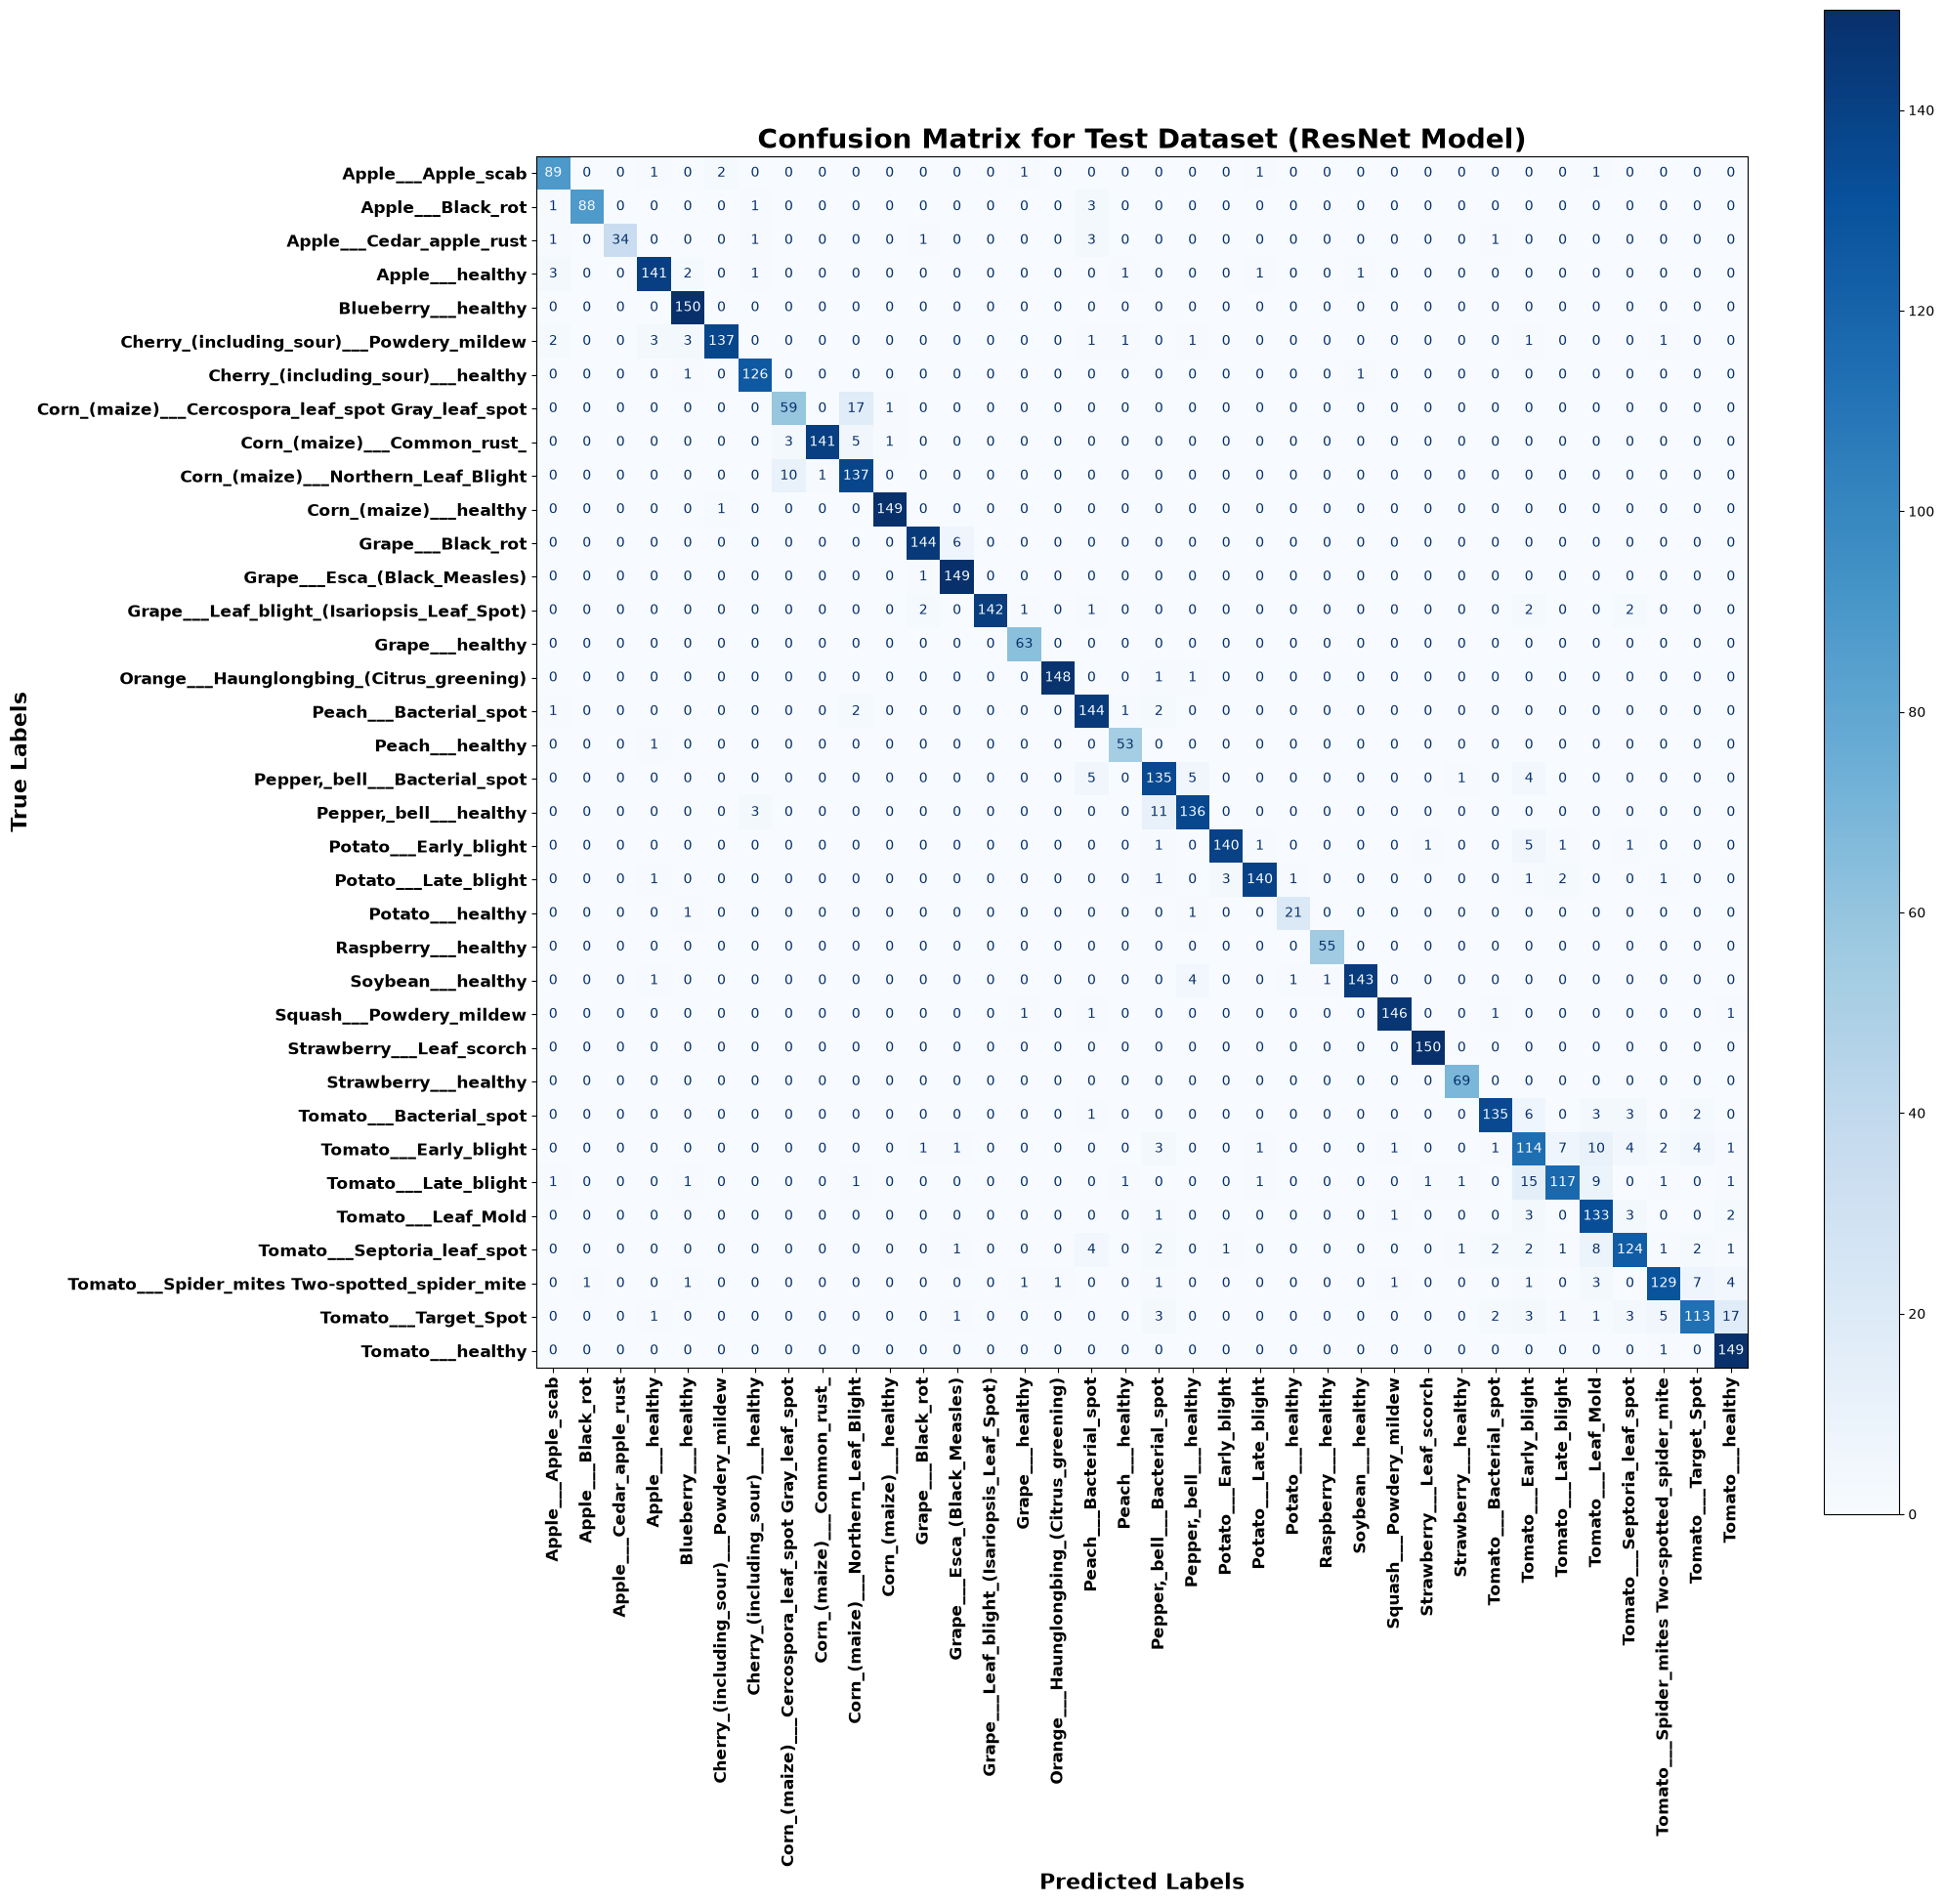

In [349]:
# Create confusion matrix
cm = confusion_matrix(all_labels, all_predicted_labels)
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix for Test Dataset (ResNet Model)", fontweight="bold", fontsize=20)

for label in ax.get_xticklabels():
    label.set_weight("bold")
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_weight("bold")
    label.set_fontsize(12)

ax.set_xlabel("Predicted Labels", fontweight="bold", fontsize=16)
ax.set_ylabel("True Labels", fontweight="bold", fontsize=16)

plt.show()

In [353]:
class_report = classification_report(all_labels, all_predicted_labels, target_names=dataset.classes)
print("Classification Report for Test Dataset (ResNet Model):")
print(class_report)

Classification Report for Test Dataset (ResNet Model):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.94      0.92        95
                                 Apple___Black_rot       0.99      0.95      0.97        93
                          Apple___Cedar_apple_rust       1.00      0.83      0.91        41
                                   Apple___healthy       0.95      0.94      0.94       150
                               Blueberry___healthy       0.94      1.00      0.97       150
          Cherry_(including_sour)___Powdery_mildew       0.98      0.91      0.94       150
                 Cherry_(including_sour)___healthy       0.95      0.98      0.97       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.77      0.79        77
                       Corn_(maize)___Common_rust_       0.99      0.94      0.97       150
               Corn_(mai

# Model 2 (EfficientNet)

In [15]:
# Load pretrained EfficientNet-B0 model from torchision
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [16]:
# Change the final layer of the model to match the number of classes in our dataset
in_features = model.classifier[1].in_features
num_classes = len(dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=in_features, out_features=num_classes)
)

# Print new final layer
print(model.classifier)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=36, bias=True)
)


In [17]:
summary(model,
         input_size=(32, 3, 224, 224),
         verbose=0,
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 36]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [22]:
# Loss function for muli-class classification
loss_fn = nn.CrossEntropyLoss()

# Optimiser for training the model
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001) # lr = learning rate

In [23]:
torch.manual_seed(42)

NUM_EPOCHS = 10

# Set device to GPU to speed up training if available
if torch.cuda.is_available():
    device = torch.device("cuda") # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Apple Silicon GPU
else:
    device = torch.device("cpu")

model = model.to(device)

best_val_accuracy = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_for_epoch(model, train_dataloader, loss_fn, optimizer, device)
    val_loss, val_accuracy = validate_for_epoch(model, val_dataloader, loss_fn, device)

    # Save the model with the best validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_efficientnet_model.pth")

    print(f"** Epoch #{epoch + 1} out of {NUM_EPOCHS} **")
    print(f"Training Loss: {train_loss:.5f} | Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.2f}%\n")

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}% at Epoch #{best_epoch}")
print(f"Model with best validation accuracy saved as 'best_efficientnet_model.pth'")

** Epoch #1 out of 10 **
Training Loss: 0.70880 | Training Accuracy: 80.24%
Validation Loss: 0.49594 | Validation Accuracy: 86.51%

** Epoch #2 out of 10 **
Training Loss: 0.61140 | Training Accuracy: 82.33%
Validation Loss: 0.45904 | Validation Accuracy: 86.53%

** Epoch #3 out of 10 **
Training Loss: 0.57527 | Training Accuracy: 83.00%
Validation Loss: 0.46003 | Validation Accuracy: 86.03%

** Epoch #4 out of 10 **
Training Loss: 0.55693 | Training Accuracy: 83.28%
Validation Loss: 0.38522 | Validation Accuracy: 88.67%

** Epoch #5 out of 10 **
Training Loss: 0.53725 | Training Accuracy: 83.77%
Validation Loss: 0.36745 | Validation Accuracy: 88.86%

** Epoch #6 out of 10 **
Training Loss: 0.53719 | Training Accuracy: 83.84%
Validation Loss: 0.36111 | Validation Accuracy: 89.41%

** Epoch #7 out of 10 **
Training Loss: 0.51974 | Training Accuracy: 84.21%
Validation Loss: 0.34745 | Validation Accuracy: 89.36%

** Epoch #8 out of 10 **
Training Loss: 0.50666 | Training Accuracy: 84.17%


In [25]:
# Reload saved model with best validation accuracy for testing
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
num_classes = len(dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=in_features, out_features=num_classes)
)

model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model = model.to(device)


In [28]:
# Test the model on the test dataset
test_loss, test_accuracy, all_labels, all_predicted_labels = test_model(model, test_dataloader, loss_fn, device)

print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.31435 | Test Accuracy: 90.26%


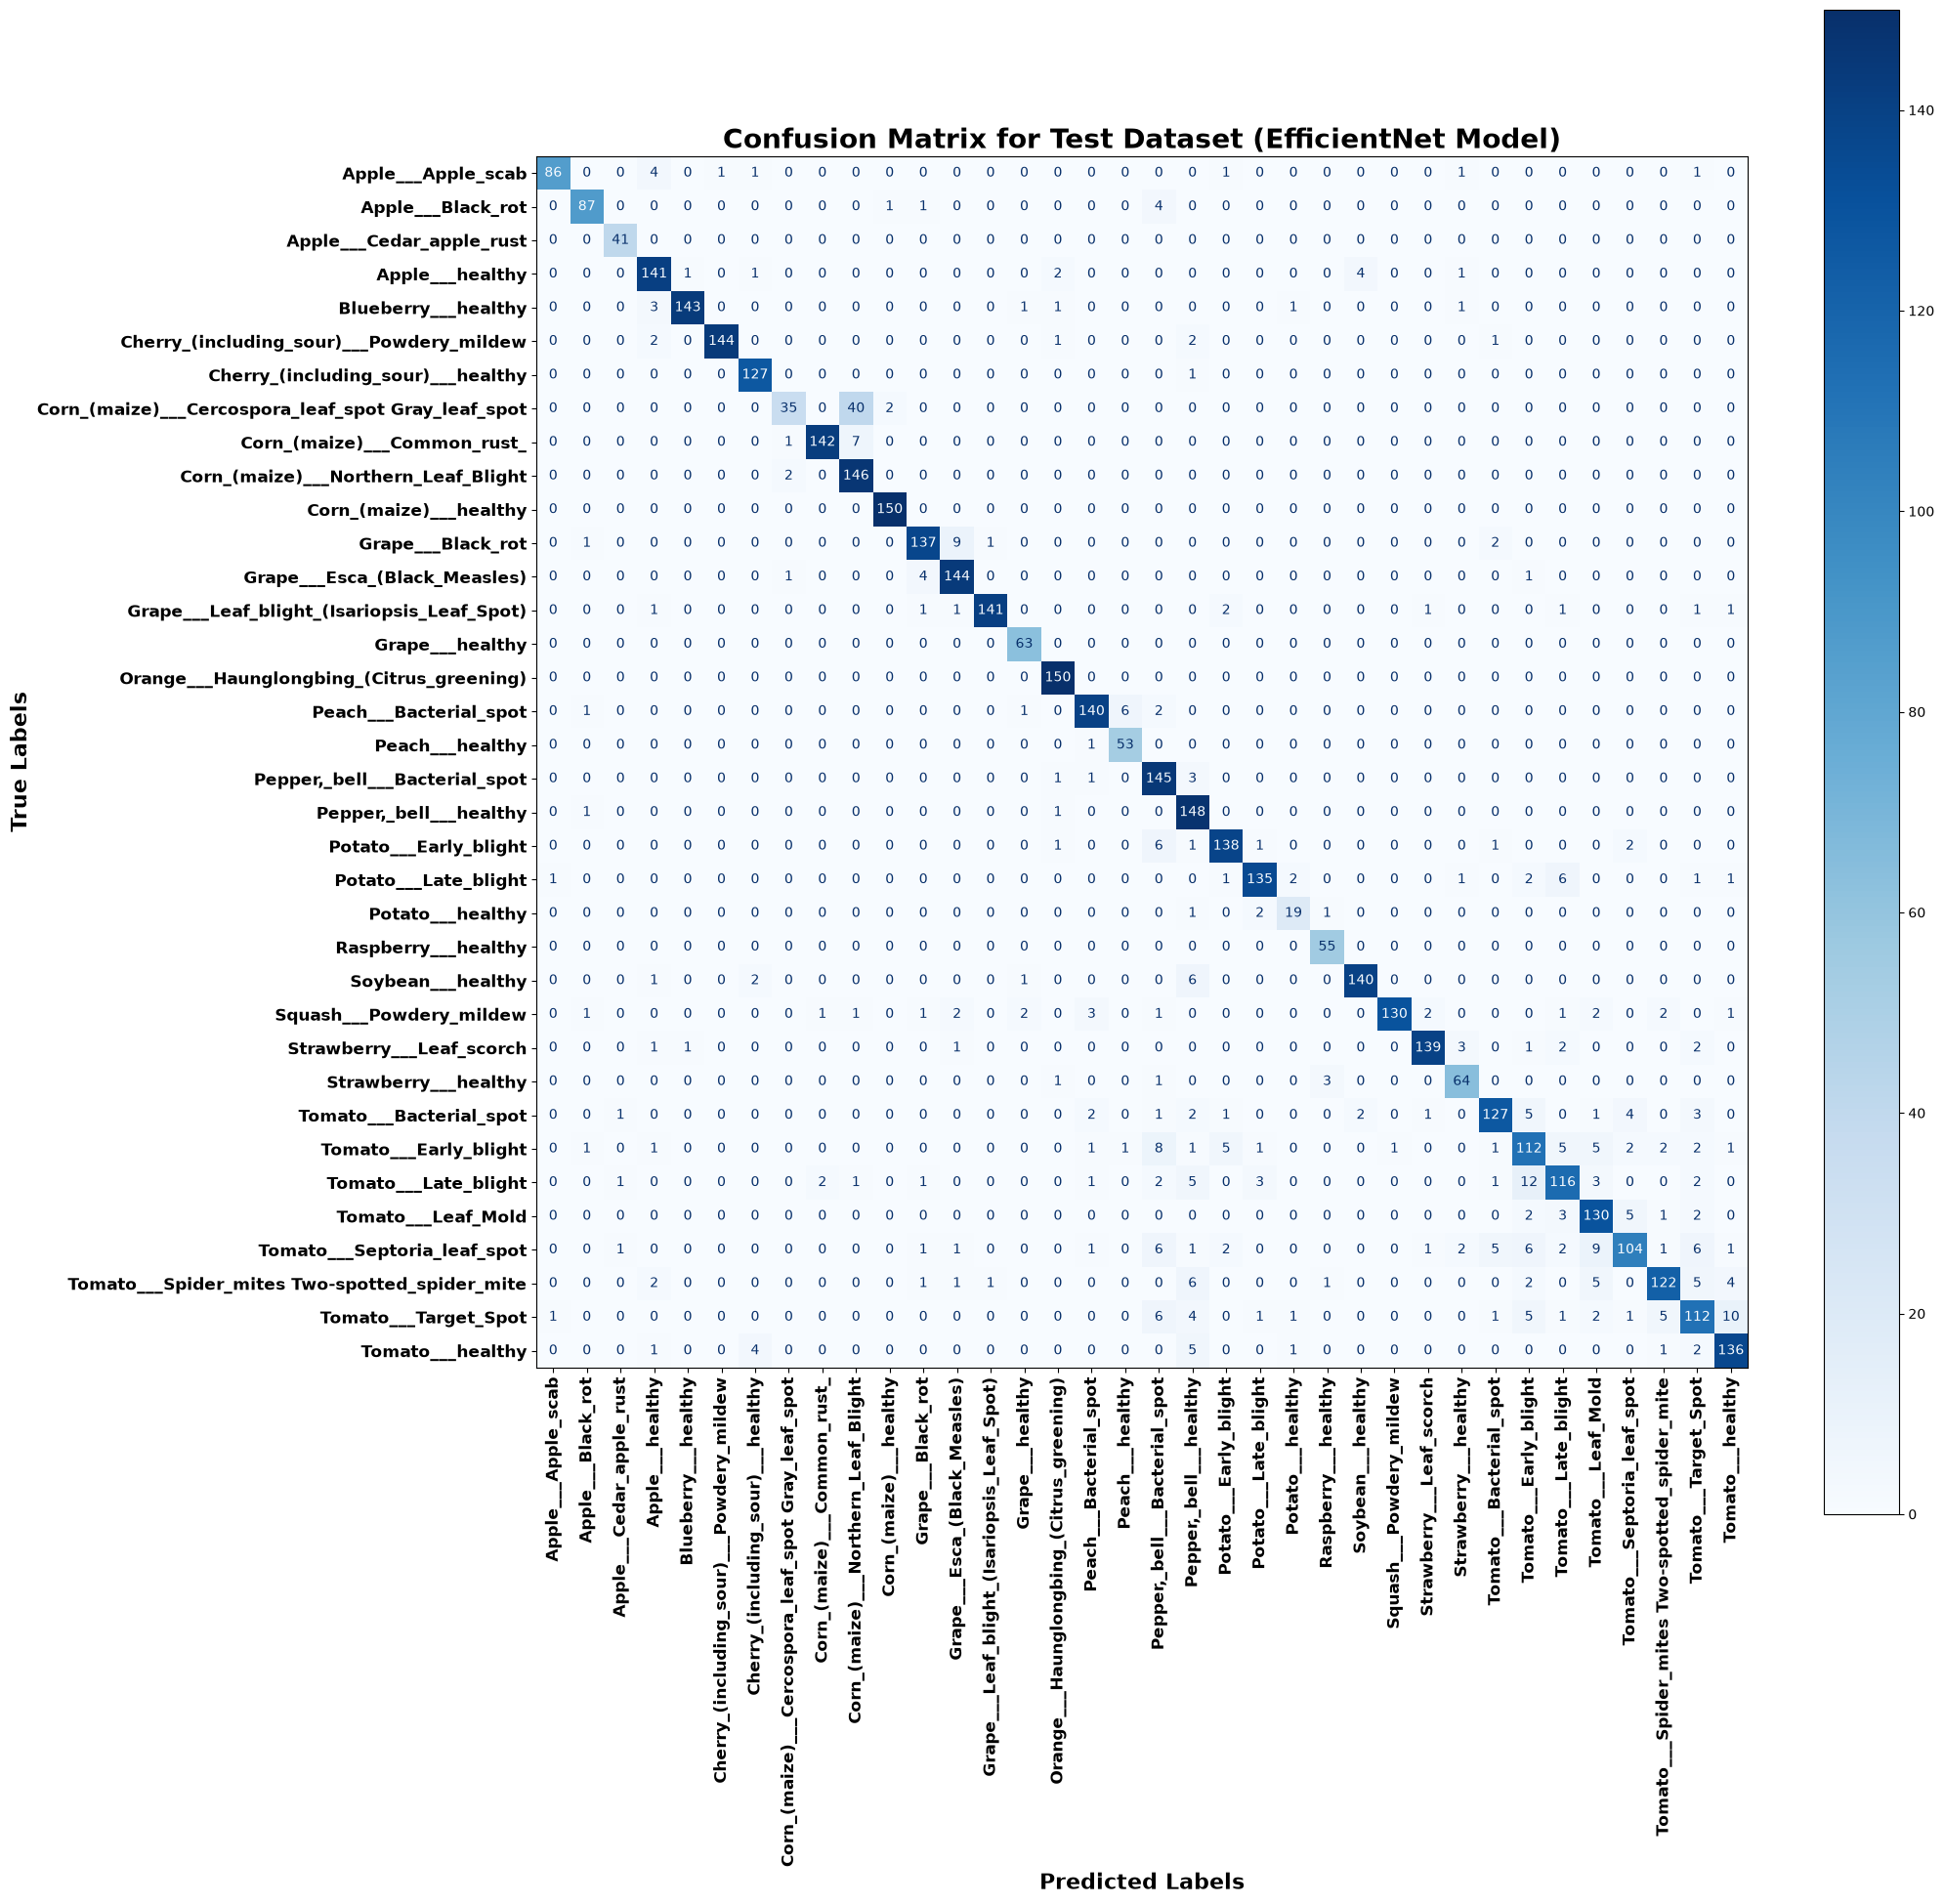

In [29]:
# Create confusion matrix
cm = confusion_matrix(all_labels, all_predicted_labels)
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix for Test Dataset (EfficientNet Model)", fontweight="bold", fontsize=20)

for label in ax.get_xticklabels():
    label.set_weight("bold")
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_weight("bold")
    label.set_fontsize(12)

ax.set_xlabel("Predicted Labels", fontweight="bold", fontsize=16)
ax.set_ylabel("True Labels", fontweight="bold", fontsize=16)

plt.show()

In [30]:
class_report = classification_report(all_labels, all_predicted_labels, target_names=dataset.classes)
print("Classification Report for Test Dataset (EfficientNet Model):")
print(class_report)

Classification Report for Test Dataset (EfficientNet Model):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.91      0.94        95
                                 Apple___Black_rot       0.95      0.94      0.94        93
                          Apple___Cedar_apple_rust       0.93      1.00      0.96        41
                                   Apple___healthy       0.90      0.94      0.92       150
                               Blueberry___healthy       0.99      0.95      0.97       150
          Cherry_(including_sour)___Powdery_mildew       0.99      0.96      0.98       150
                 Cherry_(including_sour)___healthy       0.94      0.99      0.97       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.45      0.60        77
                       Corn_(maize)___Common_rust_       0.98      0.95      0.96       150
               Cor